In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [2]:
import statsmodels.api as sm #importing by name as needed keeps namespace clean 

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF 
from statsmodels.stats.anova import anova_lm

In [10]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                        summarize,
                        poly)

In [11]:
dir() #list of objects in a namespace

['In',
 'MS',
 'NamespaceMagics',
 'Out',
 'VIF',
 '_',
 '_1',
 '_10',
 '_11',
 '_2',
 '_3',
 '_4',
 '_5',
 '_6',
 '_9',
 '__',
 '__K',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__import__',
 '__ipywidgets',
 '__loader__',
 '__name__',
 '__np',
 '__package__',
 '__pandas',
 '__pd',
 '__pyspark',
 '__session__',
 '__spec__',
 '__tf',
 '__torch',
 '__xr',
 '_attempt_import',
 '_check_imported',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_jupyterlab_variableinspector_Jupyter',
 '_jupyterlab_variableinspector_changesettings',
 '_jupyterlab_variableinspector_default',
 '_jupyterlab_variableinspector_deletevariable',
 '_jupyterlab_variableinspector_dict_list',
 '_jupyterlab_variableinspector_displaywidget',
 '_jupyterlab_variableinspector_getcontentof',
 '_jupyterlab_variableinspector_getmatrixcontent',
 '_jupyterlab_variableinspector_getshapeof',
 '_jupyterlab_variableinspector_getsizeof',


In [14]:
A = np.array([3, 5, 11])
dir(A)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',


In [15]:
#we see the in the directory of the array A we see sum so we cna write 

A.sum()

np.int64(19)

In [16]:
#construction of model matrices (aka design matrices) 

#refer to 3.6.2 for p details 

Boston = load_data('Boston')
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [17]:
Boston?

Type:        DataFrame
String form:
crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
           0    0.00632  18.0   2.3 <...> 0   5.64  23.9
           504     21.0   6.48  22.0
           505     21.0   7.88  11.9
           
           [506 rows x 13 columns]
Length:      506
File:        ~/anaconda3/lib/python3.13/site-packages/pandas/core/frame.py
Docstring:  
Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its index. T

In [19]:
#fit a simple linear regression model 
#medv is response 
#lstats is single predictor 

X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]), #fill number of rows by 1s 
                  'lstat': Boston['lstat']}) #display lstat values 
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [21]:
#extract response and fit the model

y = Boston['medv']
model = sm.OLS(y, X) #does not fit the model -specifies the model
results = model.fit() #this is used for fitting

In [22]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [23]:
#here we can translate these values as:
#when there is 0% of low status population the median value 
#of the house is 34.55 representing the intercept
#forming a line of slope -0.95, so when the lstat increases by 1%
#the median house value decreases by 0.95 units. 
#the standard error measure the precision of the coefficient approximation 
#with a coefficient of 0.039, the model fit is pretty precise
#we can also see, through the t statistic how far (how many std) 
#our coef estimate is from 0, representing a strong relationship btw variable 
#at the absolute value of t (24.528)
#finally the P value is about 0, allowing us to reject the null hypothesis 
#confirming a that the coefs differ from 0 

In [24]:
#-----------------------------------------------

In [25]:
#for multiple predictors, we may wish to introduce transformations to the variables before fitting the model 
#basically analysis including interactions btw variables and potentially expand variables into sets of variables
#sklearn about transform is created with some parameters as arguments (methods fit() and transform())

design = MS(['lstat']) #creation of the transform object 
design = design.fit(Boston) #this may initially compute mean and std for centering and scaling 
X = design.transform(Boston) #this applies the fitted transformation to the array of data and produces the model matrix 
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [26]:
#the fit method, here, simply checks that the variable 'lstat' exists in Boston 
#then transform constructs the model matrix with two columns (intercept and variable lstat)


In [28]:
#can be combined as here

design = MS(['lstat'])
design = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [29]:
#when it is done separately, the design object is changed as a result of the fit operation

In [30]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Sat, 17 Jan 2026   Prob (F-statistic):           5.08e-88
Time:                        11:47:59   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
results.params #to retreive fitted coefs 

intercept    34.553841
lstat        -0.950049
dtype: float64

In [34]:
#first create a new dataframe in the case only lstat with values at which we wish to make predictions

new_df = pd.DataFrame({'lstat':[5, 10, 15]})
#newX = design.transform(new_df) #create corresponding model matrix
newX = sm.add_constant(new_df)
newX

,const,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [39]:
#compute predictions and view by extracting predicted mean
new_predictions = results.get_prediction(newX);
new_predictions.predicted_mean #predicted values of medv when lstat = each value of the datafram (5, 10, 15)

array([29.80359411, 25.05334734, 20.30310057])

In [41]:
#we see that when predictor increases prediction decreases, negative slope

In [42]:
#produce confidence intervals with predicted values

new_predictions.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [43]:
new_predictions.conf_int(obs=True, alpha=0.05) #predition interval by setting obs to True

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

In [44]:
#they are both cented at 25.05 but the prediction interval is much wider than the confidence interval

In [47]:
#define line for plots
#ax is an axis object for an existing plot
#b is the intercept
#m is the slope of the line
def abline(ax, b, m):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, x * xlim[1] +b]
    ax.plot(xlim, ylim)

In [52]:
def abline(ax, b, m, *args, **kwargs): 
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[0] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

#args allows any number of non-named arguments to abline
#kwargs allows any number of named arguments to abline (s.a. linewidth =3) 

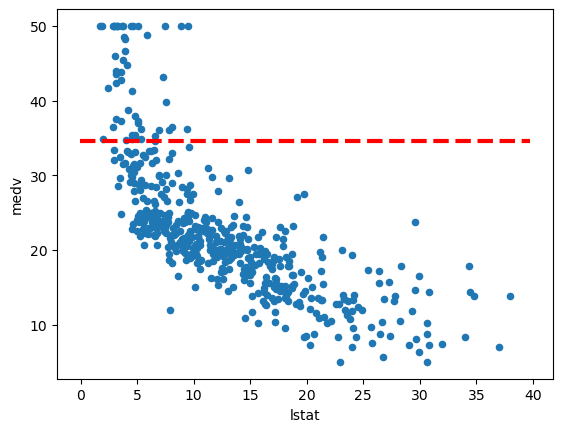

In [54]:
ax = Boston.plot.scatter('lstat', 'medv')
abline(ax, 
       results.params.iloc[0],
       results.params.iloc[1], 
       'r--', #to produce red dashed line 
       linewidth = 3) #also exists ax.axline()

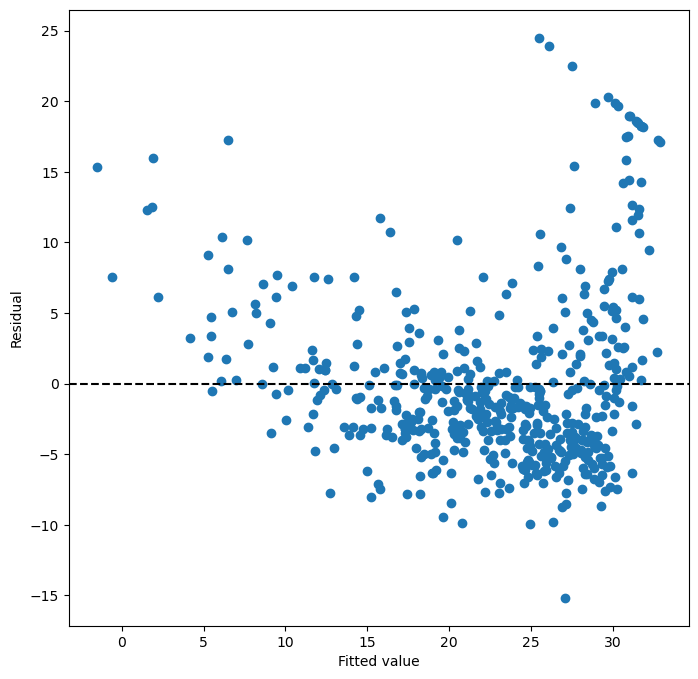

In [56]:
#can find the fitted values and residueals of the fit as attributes of the results object 
#diagnostic plots 
#influence measures of regression line 

ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

np.int64(374)

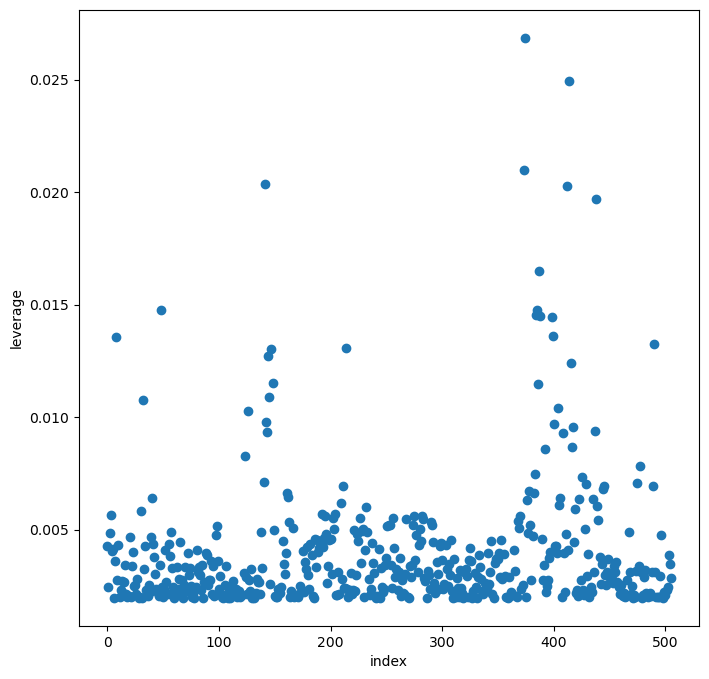

In [62]:
#on the basis of the residual plot there is some evidence of non-linearity. 
#levergae stats can be computed for any number of predictors 

infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('index')
ax.set_ylabel('leverage')
np.argmax(infl.hat_matrix_diag)

In [64]:
#hat matrix diagonal takes the y-hat (predicted) values on the diagonal representing the leverage of each observation in the dataset
#argmax identifies the indey of the largest element of an array 

#--> In this case we maximized over the entire array to determine which observation has the largest leverage statistic

In [66]:
#for least squares in multiple linear regression model, we want to construct model matrix and response
#MS is short for ModelSPec()

X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [67]:
#we cannot type this for two many variables predictors if number is high

terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

In [68]:
#fit model with all variables using the same model matrix 

X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [70]:
#if we want to run for all the variables BUT one

minus_age = Boston.columns.drop(['medv', 'age'])
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
summarize(model1.fit())

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


In [72]:
#can access individual components of results by name (dir(results) to verify what is available)
#--> results.rsquared gives R^2 and np.sqrt(results.scale) gives RSE
#--> VIF (variance inflation factors) to assess effect of collinearity 

In [73]:
#computing VIF feature in our X matrix and produce a data frame whose index agrees with the columns of X
#list comprehension can make this easier --> are simple and powerful ways to form lists of python objects


vals = [VIF(X, i)
        for i in range(1, X.shape[1])] #a dataframe or array and a variable column index as arguments (called for all col in X here)
vif = pd.DataFrame({'vif': vals}, index = X.columns[1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


In [74]:
#also

vals = []
for i in range(1, X.values.shape[1]):
    vals.append(VIF(X.values, i))

In [75]:
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


In [76]:
#interaction terms in linear model
#btw lstat and age

X = MS(['lstat', 'age', ('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


In [78]:
#non linear tranformations of predictors 
#model matrix to include terms like polynomial functions as arguments

X = MS([poly('lstat', degree = 2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [80]:
'''Key points:
- These are orthogonal polynomials, not raw polynomials (x, x²)
- Orthogonal polynomials are uncorrelated with each other
- `poly(lstat, degree=2)[0]` represents the linear effect of `lstat`
- `poly(lstat, degree=2)[1]` represents the quadratic effect of `lstat`'''

'Key points:\n- These are orthogonal polynomials, not raw polynomials (x, x²)\n- Orthogonal polynomials are uncorrelated with each other\n- `poly(lstat, degree=2)[0]` represents the linear effect of `lstat`\n- `poly(lstat, degree=2)[1]` represents the quadratic effect of `lstat`'

In [82]:
#P = 0 suggests that the quadratic term improves the model
#by default, poly() creates a basis matrix for inclusion in the model matrix 
#whose columns are orthogonal polynomials which are designed for stable least squares computations
#intercept not in poly as automatically added in MS
#using raw=True will result in lstat and lstat**2 only ->bases quadratic so no change in fitted values, only in coefs


In [84]:
#further quantify the extent to which the quadratic fit is superior to the linear fit
#can take more than two models to compare 
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


In [85]:
#run null hypothesis that bigger model not needed and alternative that it is superior
#F in this case is the square of the t-stat for the quadratic term in the linear model summary for results3
#consequence that models differ by 1 degree of freedom
#evidence that quadratic polynomal in lstat improves the linear model 
#non suprising as per non linear relationship btw lstat and medv

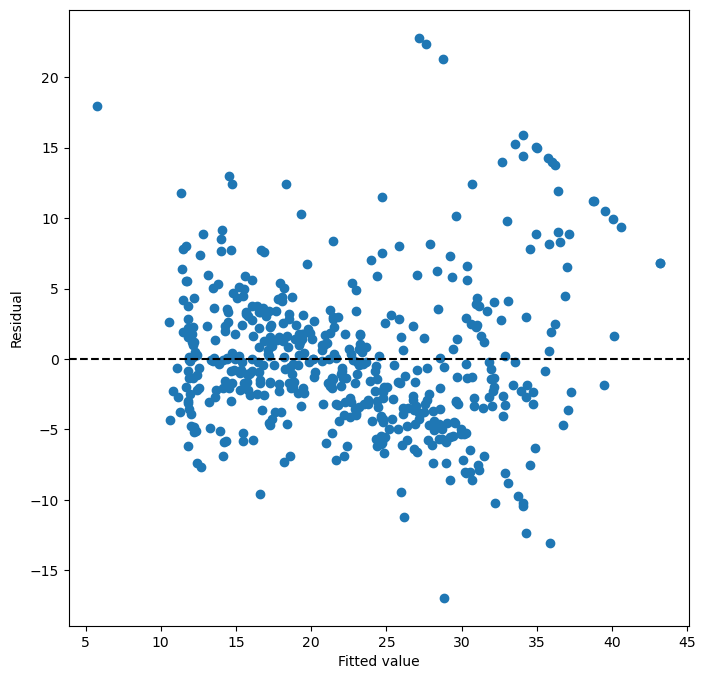

In [86]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

In [87]:
#see that when quadratic term is included there is little discernib,e pattern in the residuals 
#to add higher degree we can simply change the degree argument in poly()

In [88]:
#carseat data used now for qualitative predictors

In [89]:
Carseats = load_data('Carseats')
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [92]:
#generating dummy variable (if sum to one, called one-hot-encoding of the categorical feature)
#to avoid collinearity with an intercept the first colum is dropped

allvars = list(Carseats.columns.drop('Sales')) #make allvars a list to add interaction terms two lines down
y = Carseats['Sales']
final = allvars + [('Income', 'Advertising'),
                   ('Price', 'Age')]
X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X)
summarize(model.fit())

#model-matrix created a value of 1 if shelve good and 0 otherwise as dummy variable 
#also created a shelve medium with 1 if medium and 0 otherwise 
#and if bad it just conrespond to both being 0
#as coef for shelve good positive in regression output means associated with high sales (relative to bad loc)
#and medium positive but lower (so linked to higher sales than bad and lower sales that good) 

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288


In [93]:
#t test relationship with dependent variable and how many standard error is from 0 and direction matters
#F is model as a whole explaining significant variance -compare full model with model with only intercept 
#log likelihood is how well the model fits the observed data -higher is better 
#fitting model is finding optimal parameters (coefs) 

# Ridge and Lasso 

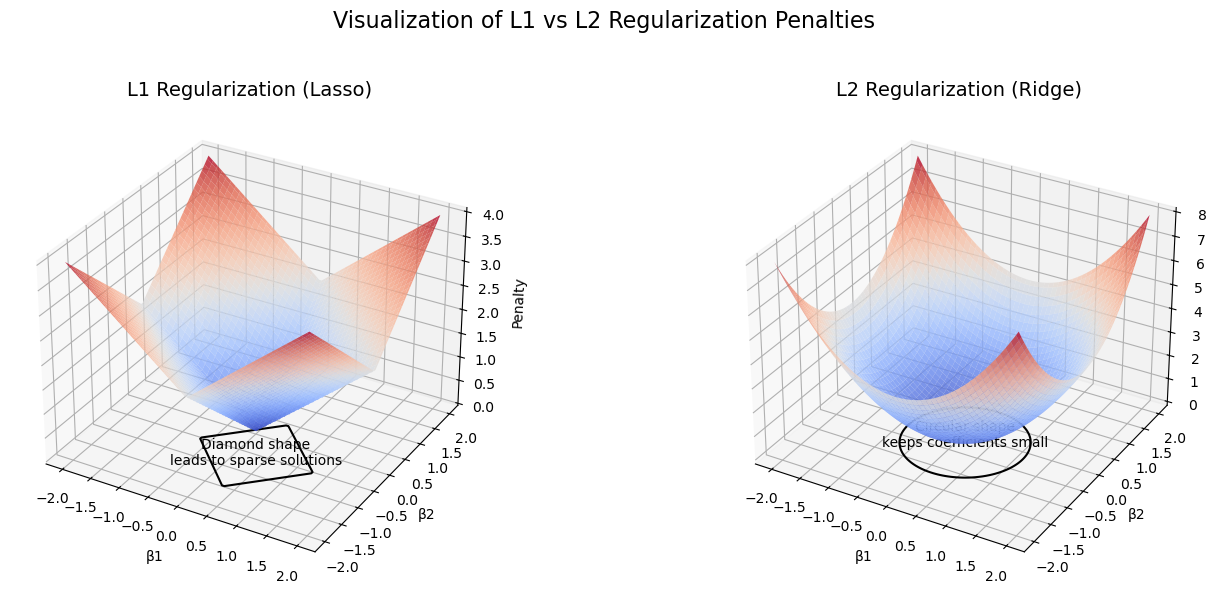

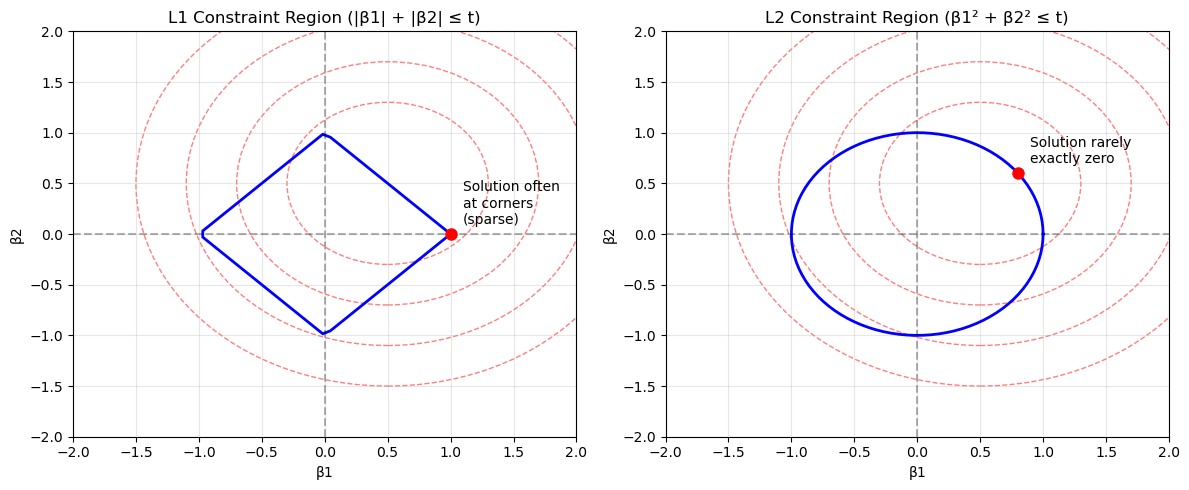

In [94]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Create a figure with two subplots
fig = plt.figure(figsize=(15, 6))

# First subplot: L1 Regularization (Lasso)
ax1 = fig.add_subplot(121, projection='3d')

# Create a meshgrid for coefficient values
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# Calculate L1 penalty: |β1| + |β2|
Z1 = np.abs(X) + np.abs(Y)

# Plot the L1 penalty surface
surf1 = ax1.plot_surface(X, Y, Z1, cmap=cm.coolwarm, alpha=0.8)
ax1.set_title('L1 Regularization (Lasso)', fontsize=14)
ax1.set_xlabel('β1')
ax1.set_ylabel('β2')
ax1.set_zlabel('Penalty')

# Add contour lines at the bottom to show the diamond shape
ax1.contour(X, Y, Z1, levels=[1.0], offset=-0.5, colors='k')
ax1.text(0, 0, -0.7, "Diamond shape\nleads to sparse solutions", 
         ha='center', fontsize=10)

# Second subplot: L2 Regularization (Ridge)
ax2 = fig.add_subplot(122, projection='3d')

# Calculate L2 penalty: β1² + β2²
Z2 = X**2 + Y**2

# Plot the L2 penalty surface
surf2 = ax2.plot_surface(X, Y, Z2, cmap=cm.coolwarm, alpha=0.8)
ax2.set_title('L2 Regularization (Ridge)', fontsize=14)
ax2.set_xlabel('β1')
ax2.set_ylabel('β2')
ax2.set_zlabel('Penalty')

# Add contour lines at the bottom to show the circular shape
ax2.contour(X, Y, Z2, levels=[1.0], offset=-0.5, colors='k')
ax2.text(0, 0, -0.7, "Circular shape\nkeeps coefficients small", 
         ha='center', fontsize=10)

# Add a title for the whole figure
plt.suptitle('Visualization of L1 vs L2 Regularization Penalties', fontsize=16)

# Adjust layout and show the plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Create a second figure to show constraint regions in 2D
plt.figure(figsize=(12, 5))

# L1 constraint region (diamond shape)
plt.subplot(121)
theta = np.linspace(0, 2*np.pi, 100)
# Parametric equation for diamond
r = 1.0 / (np.abs(np.cos(theta)) + np.abs(np.sin(theta)))
x_l1 = r * np.cos(theta)
y_l1 = r * np.sin(theta)

plt.plot(x_l1, y_l1, 'b-', linewidth=2)
plt.plot([-2, 2], [0, 0], 'k--', alpha=0.3)  # x-axis
plt.plot([0, 0], [-2, 2], 'k--', alpha=0.3)  # y-axis

# Add contours of a hypothetical loss function (circular contours)
for r in [0.8, 1.2, 1.6, 2.0]:
    circle = plt.Circle((0.5, 0.5), r, fill=False, color='r', linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)

# Mark the optimal point where contour meets constraint
plt.plot([1.0], [0.0], 'ro', markersize=8)
plt.text(1.1, 0.1, "Solution often\nat corners\n(sparse)", fontsize=10)

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.title('L1 Constraint Region (|β1| + |β2| ≤ t)')
plt.xlabel('β1')
plt.ylabel('β2')
plt.grid(True, alpha=0.3)

# L2 constraint region (circle)
plt.subplot(122)
theta = np.linspace(0, 2*np.pi, 100)
x_l2 = np.cos(theta)
y_l2 = np.sin(theta)

plt.plot(x_l2, y_l2, 'b-', linewidth=2)
plt.plot([-2, 2], [0, 0], 'k--', alpha=0.3)  # x-axis
plt.plot([0, 0], [-2, 2], 'k--', alpha=0.3)  # y-axis

# Add contours of a hypothetical loss function (circular contours)
for r in [0.8, 1.2, 1.6, 2.0]:
    circle = plt.Circle((0.5, 0.5), r, fill=False, color='r', linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)

# Mark the optimal point where contour meets constraint
plt.plot([0.8], [0.6], 'ro', markersize=8)
plt.text(0.9, 0.7, "Solution rarely\nexactly zero", fontsize=10)

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.title('L2 Constraint Region (β1² + β2² ≤ t)')
plt.xlabel('β1')
plt.ylabel('β2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()